## **NAMA : Rambu Marshanda Tamu Ina Paa**

## **NIM  : 20254920004**

---

# **SOAL 1 : Bagian A**

## Narasi Dataset

Dataset yang digunakan dalam penelitian ini adalah ulasan pengguna aplikasi Netflix yang diperoleh dari Google Play Store menggunakan Google Play Scraper. Sebanyak 1000 ulasan berhasil dikumpulkan dan digunakan sebagai data untuk analisis sentimen. Netflix merupakan salah satu platform streaming digital yang menyediakan berbagai konten hiburan seperti film, serial, dokumenter, dan acara eksklusif sehingga memiliki jumlah pengguna yang sangat besar dan aktif memberikan ulasan. Data yang diperoleh terdiri dari beberapa atribut seperti reviewId, userName, score, content, at, dan thumbsUpCount, namun penelitian ini berfokus pada atribut content sebagai sumber utama analisis teks. Berdasarkan hasil pengamatan awal, ulasan pengguna membahas berbagai aspek seperti kualitas konten, kemudahan penggunaan aplikasi, kualitas video, harga langganan, serta berbagai kendala teknis seperti buffering, gangguan saat login, dan error pada aplikasi. Keberagaman topik dan opini yang terdapat dalam ulasan tersebut menjadikan dataset Netflix cocok digunakan untuk analisis sentimen karena dapat memberikan gambaran mengenai persepsi pengguna terhadap kualitas layanan dan pengalaman penggunaan aplikasi Netflix.

---

# **SOAL 1 : Bagian B**

## Alasan Memilih Topik Netflix

Netflix dipilih sebagai objek penelitian karena merupakan salah satu aplikasi streaming yang sangat populer dan memiliki jumlah ulasan pengguna yang besar di Google Play Store. Selain itu, rating Netflix yang berada pada kisaran 3,7–4,0 menunjukkan adanya beragam pendapat dari pengguna, baik yang bersifat positif maupun negatif, sehingga menghasilkan data yang lebih seimbang untuk analisis sentimen. Ulasan pengguna juga mencakup berbagai aspek, seperti kualitas konten, kemudahan penggunaan aplikasi, harga langganan, kualitas streaming, serta kendala teknis yang dialami selama penggunaan. Keberagaman opini tersebut membuat Netflix menjadi topik yang menarik untuk dianalisis karena dapat memberikan gambaran yang lebih komprehensif mengenai tingkat kepuasan pengguna serta faktor-faktor yang memengaruhi pengalaman mereka dalam menggunakan aplikasi Netflix.

---

# **SOAL 1 : Bagian C**

## Instal Library

In [2]:
!pip install google-play-scraper pandas numpy matplotlib seaborn wordcloud nltk sastrawi vaderSentiment

In [3]:
pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


## Scraping 1000 Ulasan Netflix

In [18]:
from google_play_scraper import reviews, Sort
import pandas as pd

result, continuation_token = reviews(
    'com.netflix.mediaclient',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=1000
)

df = pd.DataFrame(result)

df = df[['content','score','at']]

df.to_csv('netflix_reviews.csv', index=False)

print("Jumlah data:", len(df))
df.head()

Jumlah data: 1000


,content,score,at
0,ini Netflix kenapa sebagian filmnya gak bisa(H...,1,2026-06-20 09:53:46
1,"Netflix offers a wide variety of movies, TV sh...",5,2026-06-20 09:22:55
2,"udah bayar, mau masuk nya malah susah banget, ...",1,2026-06-20 07:35:47
3,ok,5,2026-06-20 01:48:30
4,"film netfilk rata2 yg kurang laku dibioskop,yg...",4,2026-06-20 00:08:37


---

## Text Preprocessing

In [20]:
import pandas as pd
import re
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Stopwords
stop_words = set(stopwords.words('indonesian'))

# Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()


### Ulasan Asli

In [22]:
print(df['content'].head())

0    ini Netflix kenapa sebagian filmnya gak bisa(H...
1    Netflix offers a wide variety of movies, TV sh...
2    udah bayar, mau masuk nya malah susah banget, ...
3                                                   ok
4    film netfilk rata2 yg kurang laku dibioskop,yg...
Name: content, dtype: str


### Case Folding

In [23]:
def case_folding(text):
    return str(text).lower()

df['case_folding'] = df['content'].apply(case_folding)
print(df['case_folding'].head())

0    ini netflix kenapa sebagian filmnya gak bisa(h...
1    netflix offers a wide variety of movies, tv sh...
2    udah bayar, mau masuk nya malah susah banget, ...
3                                                   ok
4    film netfilk rata2 yg kurang laku dibioskop,yg...
Name: case_folding, dtype: str


Pada tahap *case folding*, seluruh huruf dalam ulasan diubah menjadi huruf kecil (*lowercase*). Tujuan dari proses ini adalah untuk menyeragamkan penulisan kata sehingga tidak ada perbedaan antara huruf kapital dan huruf kecil. Berdasarkan hasil yang diperoleh, tidak terlihat perubahan yang signifikan karena sebagian besar ulasan pengguna sudah ditulis menggunakan huruf kecil. Namun, proses ini tetap penting untuk memastikan konsistensi data sebelum dilakukan analisis lebih lanjut.


### Cleaning

In [24]:
def cleaning(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaning'] = df['case_folding'].apply(cleaning)
print(df['cleaning'].head())

0    ini netflix kenapa sebagian filmnya gak bisahi...
1    netflix offers a wide variety of movies tv sho...
2    udah bayar mau masuk nya malah susah banget ri...
3                                                   ok
4    film netfilk rata yg kurang laku dibioskopyg b...
Name: cleaning, dtype: str


Tahap cleaning dilakukan untuk menghapus karakter-karakter yang tidak diperlukan seperti URL, mention, hashtag, angka, tanda baca, dan karakter khusus lainnya. Hasil yang diperoleh menunjukkan bahwa ulasan menjadi lebih bersih dan hanya menyisakan kata-kata yang relevan untuk analisis. Sebagai contoh, ulasan yang mengandung tanda baca atau karakter tambahan telah diubah menjadi kalimat sederhana yang lebih mudah diproses pada tahap berikutnya.

### Tokenization

In [25]:
def tokenization(text):
    return text.split()

df['tokenization'] = df['cleaning'].apply(tokenization)
print(df['tokenization'].head())

0    [ini, netflix, kenapa, sebagian, filmnya, gak,...
1    [netflix, offers, a, wide, variety, of, movies...
2    [udah, bayar, mau, masuk, nya, malah, susah, b...
3                                                 [ok]
4    [film, netfilk, rata, yg, kurang, laku, dibios...
Name: tokenization, dtype: object


Pada tahap tokenization, setiap kalimat dipecah menjadi kumpulan kata atau token. Hasil tokenisasi menunjukkan bahwa setiap ulasan yang semula berupa kalimat utuh berubah menjadi daftar kata, misalnya ulasan "setiap login ada kesalahan terus aneh" menjadi ['setiap', 'login', 'ada', 'kesalahan', 'terus', 'aneh']. Proses ini bertujuan untuk memudahkan pengolahan teks pada tahap selanjutnya seperti penghapusan stopword dan stemming.

### Stopword Removal

In [26]:
def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

df['stopword_removal'] = df['tokenization'].apply(remove_stopwords)
print(df['stopword_removal'].head())

0    [netflix, filmnya, gak, bisahistory, tontonan,...
1    [netflix, offers, a, wide, variety, of, movies...
2    [udah, bayar, masuk, nya, susah, banget, ribee...
3                                                 [ok]
4    [film, netfilk, yg, laku, dibioskopyg, bagus, ...
Name: stopword_removal, dtype: object


Tahap stopword removal dilakukan untuk menghapus kata-kata yang sering muncul namun tidak memiliki kontribusi besar terhadap makna sentimen, seperti "ini", "malah", "rata", dan kata umum lainnya. Setelah proses ini dilakukan, kata-kata yang dianggap tidak penting dihilangkan sehingga hanya tersisa kata-kata yang lebih representatif terhadap isi ulasan. Contohnya, token [film, netfilk, rata, yg, kurang, laku, dibios...] berubah menjadi [film, netfilk, yg, laku, dibioskopyg, bagus, ...].

### Stemming

In [30]:
def stemming(tokens):
    return [stemmer.stem(word) for word in tokens]

df['stemming'] = df['stopword_removal'].apply(stemming)
print(df['stemming'].head())

0    [netflix, film, gak, bisahistory, tonton, lanj...
1    [netflix, offers, a, wide, variety, of, movies...
2    [udah, bayar, masuk, nya, susah, banget, ribee...
3                                                 [ok]
4    [film, netfilk, yg, laku, dibioskopyg, bagus, ...
Name: stemming, dtype: object


Pada tahap stemming, setiap kata diubah menjadi bentuk dasarnya. Misalnya kata " filmnya" diubah menjadi "film", "tontonan" menjadi "tonton", dan lainnya. Hasil stemming menunjukkan bahwa variasi kata dengan makna yang sama dapat disatukan ke dalam satu bentuk dasar sehingga analisis menjadi lebih akurat dan efisien.

### Gabungkan hasil akhir

In [31]:
df['clean_review'] = df['stemming'].apply(lambda x: ' '.join(x))
print(df['clean_review'].head())

0    netflix film gak bisahistory tonton lanjut hil...
1    netflix offers a wide variety of movies tv sho...
2    udah bayar masuk nya susah banget ribeeeeet ap...
3                                                   ok
4    film netfilk yg laku dibioskopyg bagus action ...
Name: clean_review, dtype: str


Setelah seluruh tahapan preprocessing dilakukan, diperoleh teks yang lebih bersih dan terstruktur. Contohnya, ulasan "ini Netflix kenapa sebagian filmnya gak bisa(H..." berubah menjadi "netflix film gak bisahistory tonton lanjut hil...". Hasil akhir ini menunjukkan bahwa data telah siap digunakan untuk proses visualisasi WordCloud dan analisis sentimen. Secara umum, preprocessing berhasil mengurangi kata-kata yang tidak relevan serta mempertahankan informasi penting yang dapat digunakan untuk mengidentifikasi opini pengguna terhadap aplikasi Netflix.

# **SOAL 1 : Bagian D**

## WordCloud

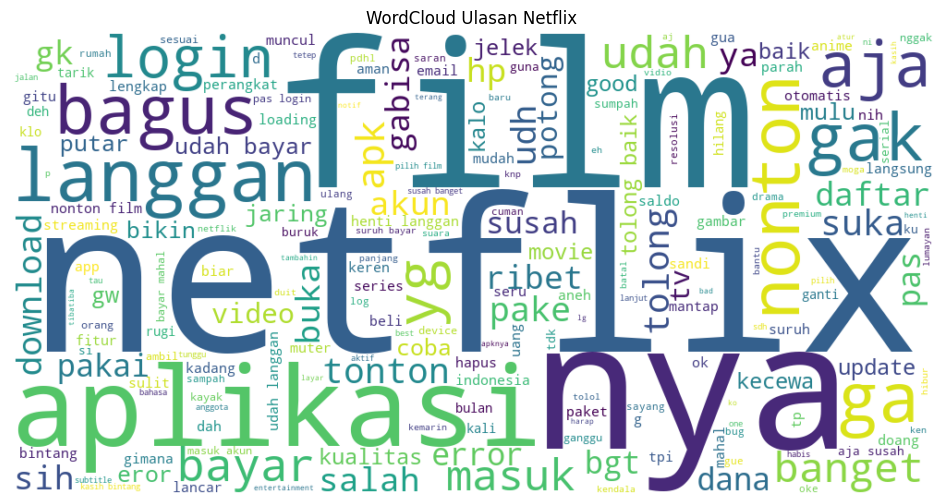

In [32]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = ' '.join(df['clean_review'])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud Ulasan Netflix')
plt.show()

Berdasarkan hasil WordCloud, kata yang paling sering muncul adalah "netflix", "film", "nonton", "aplikasi", dan "langgan". Hal ini menunjukkan bahwa sebagian besar pengguna membahas pengalaman menonton film serta layanan berlangganan yang disediakan oleh Netflix.
Selain itu, terdapat kata-kata seperti "bagus", "suka", dan "baik" yang menunjukkan adanya kepuasan pengguna terhadap aplikasi. Namun, muncul juga kata-kata seperti "login", "error", "masuk", "bayar", dan "kecewa" yang mengindikasikan adanya keluhan terkait masalah teknis dan pembayaran.
Secara keseluruhan, WordCloud menunjukkan bahwa ulasan pengguna Netflix didominasi oleh pembahasan mengenai kualitas layanan menonton, sistem berlangganan, serta beberapa kendala teknis yang dialami pengguna.

# **SOAL 1 : Bagian E**

## Analisis Sentimen

In [33]:
from textblob import TextBlob

# Fungsi sentimen
def get_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity

    if polarity > 0:
        return 'Positif'
    elif polarity < 0:
        return 'Negatif'
    else:
        return 'Netral'

# Menentukan sentimen
df['sentiment'] = df['clean_review'].apply(get_sentiment)

# Menampilkan hasil
print(df[['clean_review', 'sentiment']].head(20))

                                         clean_review sentiment
0   netflix film gak bisahistory tonton lanjut hil...    Netral
1   netflix offers a wide variety of movies tv sho...   Positif
2   udah bayar masuk nya susah banget ribeeeeet ap...    Netral
3                                                  ok   Positif
4   film netfilk yg laku dibioskopyg bagus action ...   Positif
5                        saran film rating nilai film    Netral
6   bagus saran category filter nya tambah negara ...   Positif
7                                             lumayan    Netral
8                                                        Netral
9                                               bagus    Netral
10           mantapz sesuai butuh mantap sesuai butuh    Netral
11                                   login salah aneh    Netral
12                              ribet susah nak masuk    Netral
13                         aplikasi nonton film cacat    Netral
14     bs ga sih bayar langgan nya tuh g

In [37]:
sentiment_count = df['sentiment'].value_counts()
print(df.columns.tolist())
print(df[['clean_review']].head())
print(sentiment_count)
df.to_csv("netflix_sentiment.csv", index=False)

['content', 'score', 'at', 'case_folding', 'cleaning', 'tokenization', 'stopword_removal', 'stemming', 'clean_review', 'sentiment']
                                        clean_review
0  netflix film gak bisahistory tonton lanjut hil...
1  netflix offers a wide variety of movies tv sho...
2  udah bayar masuk nya susah banget ribeeeeet ap...
3                                                 ok
4  film netfilk yg laku dibioskopyg bagus action ...
sentiment
Netral     873
Positif     94
Negatif     33
Name: count, dtype: int64


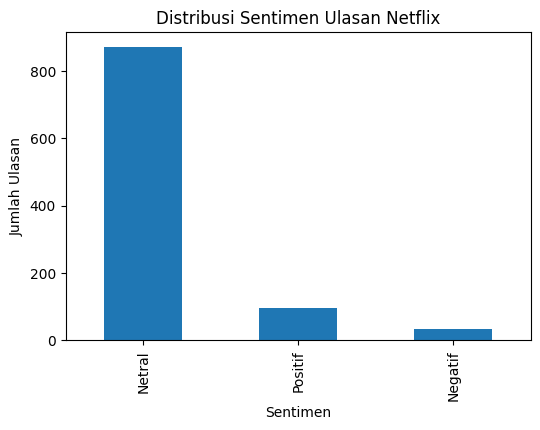

In [35]:
import matplotlib.pyplot as plt

sentiment_count.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Distribusi Sentimen Ulasan Netflix')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Ulasan')
plt.show()

In [36]:
persentase = round(
    df['sentiment'].value_counts(normalize=True) * 100,
    2
)

print(persentase)

sentiment
Netral     87.3
Positif     9.4
Negatif     3.3
Name: proportion, dtype: float64


### Penjelasan

Analisis sentimen dilakukan terhadap 1000 ulasan pengguna Netflix yang telah melalui tahap preprocessing. Hasil analisis menunjukkan bahwa sebagian besar ulasan termasuk dalam kategori netral, yaitu sebanyak 873 ulasan (87,3%). Ulasan netral umumnya berisi komentar, pertanyaan, atau pengalaman pengguna yang tidak menunjukkan kecenderungan sentimen positif maupun negatif secara jelas.

Sementara itu, terdapat 94 ulasan (9,4%) yang termasuk dalam kategori positif. Ulasan positif umumnya berisi apresiasi terhadap kualitas film, kemudahan menonton, serta pengalaman pengguna yang memuaskan saat menggunakan aplikasi Netflix. Selain itu, terdapat 33 ulasan (3,3%) yang termasuk dalam kategori negatif, yang sebagian besar berkaitan dengan kendala login, masalah pembayaran langganan, error aplikasi, dan kesulitan mengakses layanan.

Secara keseluruhan, hasil analisis sentimen menunjukkan bahwa ulasan pengguna Netflix didominasi oleh sentimen netral. Hal ini mengindikasikan bahwa sebagian besar pengguna memberikan komentar yang bersifat informatif atau deskriptif, sementara jumlah ulasan positif lebih banyak dibandingkan ulasan negatif, sehingga dapat dikatakan bahwa tanggapan pengguna terhadap aplikasi Netflix cenderung baik meskipun masih terdapat beberapa keluhan terkait aspek teknis dan layanan.